   CustomerID     Name  Age Gender    Country  Annual_Income  \
0           1    Alice   28      F        USA          55000   
1           2      Bob   35      M     Canada          62000   
2           3  Charlie   22      M         UK          30000   
3           4    Diana   20      F        USA          46000   
4           5    Ethan   32      M  Australia          74000   

  Product_Purchased Purchase_Date  
0            Laptop    2024-02-10  
1        Smartphone    2024-03-12  
2            Tablet    2024-01-22  
3        Smartphone    2024-01-28  
4           Speaker    2024-01-04  

->Average of Annual income: 55433.333333333336

->Unique countries: ['Australia' 'Canada' 'France' 'Germany' 'India' 'UK' 'USA']

->Number of customers belonging to each country: {'USA': 8, 'Canada': 5, 'UK': 4, 'Australia': 3, 'India': 4, 'Germany': 3, 'France': 3}

->Category of employees based on salary above or below 60,000:
Alice - Low Income
Bob - High Income
Charlie - Low Income
Diana - L

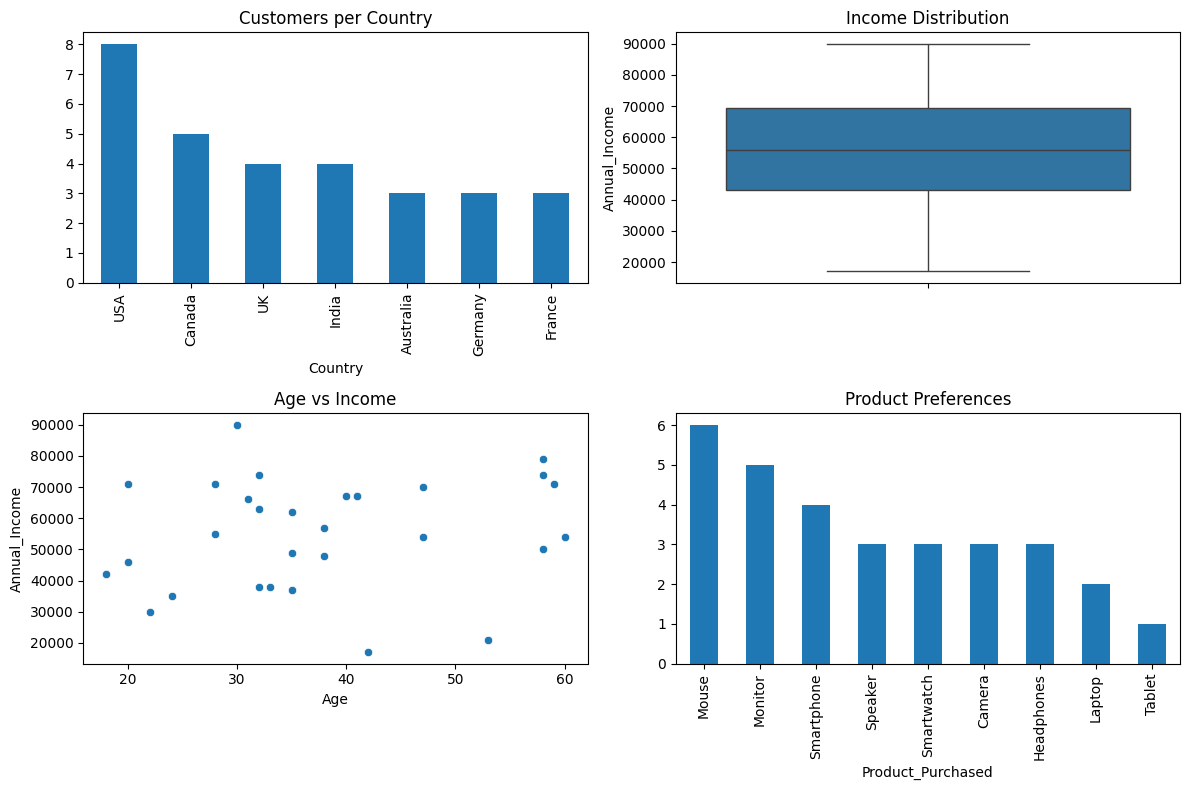

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_excel("customer_dataset.xlsx")
print(df.head())
avg_income=np.mean(df['Annual_Income'])
print("\n->Average of Annual income:",avg_income)
countries=np.unique(df['Country'])
print("\n->Unique countries:",countries)
country_count={}
for index,row in df.iterrows():
        country = row["Country"]
        if country in country_count:
            country_count[country] += 1
        else:
            country_count[country] = 1
print("\n->Number of customers belonging to each country:",country_count)
print("\n->Category of employees based on salary above or below 60,000:")
for _, row in df.iterrows():
    name = row["Name"]
    income = row["Annual_Income"] 
    if income > 60000:
        print(name, "- High Income")
    else:
        print(name, "- Low Income")
age_std=np.std(df["Age"])
income_std=np.std(df["Annual_Income"])
print("\n->Standard deviation of Age:",age_std)
print("\n->Standard deviation of Annual Income:",income_std)
print("\n->Dataset with Customers with age above 40:")
print(df[df["Age"] > 40])
df["Income Category"] = np.where(df["Annual_Income"] > 60000, "High", "Low")
print("\n->Updated Dataset with Income Category:\n", df)
duplicates = df.duplicated(subset="CustomerID")
print("\n->Duplicate rows:\n", df[duplicates])
df = df.drop_duplicates(subset="CustomerID")
df["Product_Purchased"] = df["Product_Purchased"].fillna("Unknown")
df["Purchase_Date"] = pd.to_datetime(df["Purchase_Date"])
print("\n->Cleaned Dataset:\n", df)

print("\n->Mean:\n", df[["Age", "Annual_Income"]].mean())
print("\n->Median:\n", df[["Age", "Annual_Income"]].median())
print("\n->Mode:\n", df[["Age", "Annual_Income"]].mode())
print("\n->Correlation:\n", df[["Age", "Annual_Income"]].corr())
print("\n->Average Income per Country:")
print(df.groupby("Country")["Annual_Income"].mean())

df["Year"] = df["Purchase_Date"].dt.year
df["Month"] = df["Purchase_Date"].dt.month
print("\n->Summary Statistics:\n", df.describe())

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
df["Country"].value_counts().plot(kind="bar")
plt.title("Customers per Country")
plt.subplot(2, 2, 2)
sns.boxplot(y=df["Annual_Income"])
plt.title("Income Distribution")
plt.subplot(2, 2, 3)
sns.scatterplot(x="Age", y="Annual_Income", data=df)
plt.title("Age vs Income")
plt.subplot(2, 2, 4)
df["Product_Purchased"].value_counts().plot(kind="bar")
plt.title("Product Preferences")
plt.tight_layout()
plt.show()